# Data Preparation

In [95]:
import json


def get_dataset(filepath):
    with open(filepath, "r") as file:
        dataset = json.load(file)
    labels = [item["label"] for item in dataset]
    texts = [item["task"] for item in dataset]
    return labels, texts

In [96]:
# Load datasets
train_labels, train_texts = get_dataset("./data/alfred/train.json")
test_seen_labels, test_seen_texts = get_dataset("./data/alfred/valid_seen.json")
test_unseen_labels, test_unseen_texts = get_dataset("./data/alfred/valid_unseen.json")

In [97]:
# Stop words
import json

with open("data/stopwords.json", "r") as file:
    stopwords = json.load(file)

# TF-IDF model

In [98]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

uni_vectorizer = TfidfVectorizer(
    stop_words=list(stopwords),
    max_features=5000,
    ngram_range=(1, 1),
    norm=None,
)
train_tfidf = uni_vectorizer.fit_transform(train_texts)
test_seen_tfidf = uni_vectorizer.transform(test_seen_texts)
test_unseen_tfidf = uni_vectorizer.transform(test_unseen_texts)

counter = CountVectorizer(vocabulary=uni_vectorizer.vocabulary_)
test_seen_tf = counter.fit_transform(test_seen_texts)
test_unseen_tf = counter.fit_transform(test_unseen_texts)

In [99]:
import numpy as np
from scipy import sparse
from sklearn.preprocessing import normalize

labels = list(set(train_labels))
label_index = {label: i for i, label in enumerate(labels)}
row_indices = [label_index[l] for l in train_labels]
col_indices = range(len(train_labels))
indicator_mat = sparse.csr_matrix(
    (np.ones(len(train_labels)), (row_indices, col_indices)),
    shape=(len(labels), len(train_labels)),
)

# Normalize all tf-idf vectors to unit length
test_seen_tfidf = normalize(test_seen_tfidf, norm="l2", axis=1)
test_unseen_tfidf = normalize(test_unseen_tfidf, norm="l2", axis=1)
label_tfidf = normalize(indicator_mat @ train_tfidf, norm="l2", axis=1)

In [100]:
print("Train shape:", train_tfidf.shape)
print("Seen shape:", test_seen_tf.shape)
print("Unseen shape:", test_unseen_tf.shape)
print("Label shape:", label_tfidf.shape)

Train shape: (21025, 1084)
Seen shape: (820, 1084)
Unseen shape: (821, 1084)
Label shape: (7, 1084)


Predict using TF-IDF score

In [ ]:
import numpy as np

seen_pred = np.argmax(test_seen_tf @ label_tfidf.T, axis=1).A1
seen_pred_labels = [labels[i] for i in seen_pred]

X_unseen_predict = np.argmax(test_unseen_tf @ label_tfidf.T, axis=1).A1
X_unseen_predict_labels = [labels[i] for i in X_unseen_predict]

In [ ]:
from sklearn.metrics import accuracy_score

seen_score = accuracy_score(test_seen_labels, seen_pred_labels)
unseen_score = accuracy_score(test_unseen_labels, X_unseen_predict_labels)
print(f"Seen Accuracy: {seen_score:.2%}")
print(f"Unseen Accuracy: {unseen_score:.2%}")

Seen Accuracy: 78.41%
Unseen Accuracy: 85.26%


Predicting using TF-IDF vector similarities

In [ ]:
import numpy as np

seen_pred = np.argmax(test_seen_tfidf @ label_tfidf.T, axis=1).A1
seen_pred_labels = [labels[i] for i in seen_pred]

X_unseen_predict = np.argmax(test_unseen_tfidf @ label_tfidf.T, axis=1).A1
X_unseen_predict_labels = [labels[i] for i in X_unseen_predict]

In [ ]:
from sklearn.metrics import accuracy_score

seen_score = accuracy_score(test_seen_labels, seen_pred_labels)
unseen_score = accuracy_score(test_unseen_labels, X_unseen_predict_labels)
print(f"Seen Accuracy: {seen_score:.2%}")
print(f"Unseen Accuracy: {unseen_score:.2%}")

Seen Accuracy: 81.83%
Unseen Accuracy: 88.67%


# TF-IDF with unigram and bigram

In [105]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

bi_vectorizer = TfidfVectorizer(
    stop_words=list(stopwords),
    max_features=5000,
    ngram_range=(1, 2),
    norm=None,
)
train_tfidf = bi_vectorizer.fit_transform(train_texts)
test_seen_tfidf = bi_vectorizer.transform(test_seen_texts)
test_unseen_tfidf = bi_vectorizer.transform(test_unseen_texts)

counter = CountVectorizer(vocabulary=bi_vectorizer.vocabulary_)
test_seen_tf = counter.fit_transform(test_seen_texts)
test_unseen_tf = counter.fit_transform(test_unseen_texts)

In [106]:
import numpy as np
from scipy import sparse
from sklearn.preprocessing import normalize

labels = list(set(train_labels))
label_index = {label: i for i, label in enumerate(labels)}
row_indices = [label_index[l] for l in train_labels]
col_indices = range(len(train_labels))
indicator_mat = sparse.csr_matrix(
    (np.ones(len(train_labels)), (row_indices, col_indices)),
    shape=(len(labels), len(train_labels)),
)

# Normalize all tf-idf vectors to unit length
test_seen_tfidf = normalize(test_seen_tfidf, norm="l2", axis=1)
test_unseen_tfidf = normalize(test_unseen_tfidf, norm="l2", axis=1)
label_tfidf = normalize(indicator_mat @ train_tfidf, norm="l2", axis=1)

In [107]:
print("Train shape:", train_tfidf.shape)
print("Seen shape:", test_seen_tf.shape)
print("Unseen shape:", test_unseen_tf.shape)
print("Label shape:", label_tfidf.shape)

Train shape: (21025, 5000)
Seen shape: (820, 5000)
Unseen shape: (821, 5000)
Label shape: (7, 5000)


Predict using TF-IDF score

In [ ]:
import numpy as np

seen_pred = np.argmax(test_seen_tf @ label_tfidf.T, axis=1).A1
seen_pred_labels = [labels[i] for i in seen_pred]

X_unseen_predict = np.argmax(test_unseen_tf @ label_tfidf.T, axis=1).A1
X_unseen_predict_labels = [labels[i] for i in X_unseen_predict]

In [ ]:
from sklearn.metrics import accuracy_score

seen_score = accuracy_score(test_seen_labels, seen_pred_labels)
unseen_score = accuracy_score(test_unseen_labels, X_unseen_predict_labels)
print(f"Seen Accuracy: {seen_score:.2%}")
print(f"Unseen Accuracy: {unseen_score:.2%}")

Seen Accuracy: 77.93%
Unseen Accuracy: 84.90%


Predicting using TF-IDF vector similarities

In [ ]:
import numpy as np

seen_pred = np.argmax(test_seen_tfidf @ label_tfidf.T, axis=1).A1
seen_pred_labels = [labels[i] for i in seen_pred]

X_unseen_predict = np.argmax(test_unseen_tfidf @ label_tfidf.T, axis=1).A1
X_unseen_predict_labels = [labels[i] for i in X_unseen_predict]

In [ ]:
from sklearn.metrics import accuracy_score

seen_score = accuracy_score(test_seen_labels, seen_pred_labels)
unseen_score = accuracy_score(test_unseen_labels, X_unseen_predict_labels)
print(f"Seen Accuracy: {seen_score:.2%}")
print(f"Unseen Accuracy: {unseen_score:.2%}")

Seen Accuracy: 84.27%
Unseen Accuracy: 91.47%


# Model Inspect

In [112]:
for a, b in zip(
    uni_vectorizer.get_feature_names_out(), bi_vectorizer.get_feature_names_out()
):
    print(f"{a:>20} | {b}")

                 2nd | across
          abandoning | across fridge
                able | across room
            abstract | adjacent
                  ac | afterwards
             acquire | alarm
              across | alarm clock
                  ad | alarm clocks
            addition | along
            adjacent | along cardboard
              adjust | along knife
          afterwards | another
               ahead | another desk
               alarm | another table
               along | apple
             already | apple bin
                also | apple black
               angle | apple blue
             another | apple bowl
               apple | apple chill
              apples | apple cook
                area | apple cool
               areas | apple counter
                 arm | apple fridge
            armchair | apple garbage
              around | apple inside
           arranging | apple kitchen
                 ash | apple knife
              attach | apple microwave


# Dimension

In [140]:
import itertools as itt

vector_dimensions = [
    x * y for x, y in (itt.product([1, 10, 100], [10, 16, 25, 40, 63]))
] + [10000]

In [149]:
import numpy as np
from scipy import sparse
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import normalize
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer


class TfidfModel:
    labels = list(set(train_labels))
    label_index = {label: i for i, label in enumerate(labels)}
    row_indices = [label_index[l] for l in train_labels]
    col_indices = range(len(train_labels))
    indicator_mat = sparse.csr_matrix(
        (np.ones(len(train_labels)), (row_indices, col_indices)),
        shape=(len(labels), len(train_labels)),
    )

    def __init__(self, max_features, ngram_range=(1, 1)):
        self.vectorizer = TfidfVectorizer(
            stop_words=list(stopwords),
            max_features=max_features,
            ngram_range=ngram_range,
            norm=None,
        )
        self.train_tfidf = self.vectorizer.fit_transform(train_texts)
        self.counter = CountVectorizer(vocabulary=self.vectorizer.vocabulary_)
        self.dim = self.vectorizer.get_feature_names_out().size

    def prep_data(self):
        self.test_seen_tfidf = normalize(
            self.vectorizer.transform(test_seen_texts), norm="l2", axis=1
        )
        self.test_unseen_tfidf = normalize(
            self.vectorizer.transform(test_unseen_texts), norm="l2", axis=1
        )
        self.label_tfidf = normalize(
            self.indicator_mat @ self.train_tfidf, norm="l2", axis=1
        )
        self.train_tfidf = normalize(self.train_tfidf, norm="l2", axis=1)
        self.test_seen_tf = self.counter.fit_transform(test_seen_texts)
        self.test_unseen_tf = self.counter.fit_transform(test_unseen_texts)

    def predict_scores(self):
        self.seen_pred = np.argmax(self.test_seen_tf @ self.label_tfidf.T, axis=1).A1
        self.seen_pred_labels = [self.labels[i] for i in self.seen_pred]

        self.unseen_pred = np.argmax(
            self.test_unseen_tf @ self.label_tfidf.T, axis=1
        ).A1
        self.unseen_pred_labels = [self.labels[i] for i in self.unseen_pred]
        return (
            accuracy_score(test_seen_labels, self.seen_pred_labels),
            accuracy_score(test_unseen_labels, self.unseen_pred_labels),
        )

    def predict_similarity(self):
        self.seen_pred = np.argmax(self.test_seen_tfidf @ self.label_tfidf.T, axis=1).A1
        self.seen_pred_labels = [self.labels[i] for i in self.seen_pred]

        self.unseen_pred = np.argmax(
            self.test_unseen_tfidf @ self.label_tfidf.T, axis=1
        ).A1
        self.unseen_pred_labels = [self.labels[i] for i in self.unseen_pred]
        return (
            accuracy_score(test_seen_labels, self.seen_pred_labels),
            accuracy_score(test_unseen_labels, self.unseen_pred_labels),
        )

    def evaluate(self):
        self.prep_data()
        score_scores = self.predict_scores()
        score_similarity = self.predict_similarity()
        return score_scores + score_similarity

    def print_vocab(self):
        print(self.vectorizer.get_feature_names_out())

In [156]:
data_records = []
for ngrams in [(1, 1), (1, 2)]:
    for dim in vector_dimensions:
        model = TfidfModel(max_features=dim, ngram_range=ngrams)
        seen_score, unseen_score, seen_sim, unseen_sim = model.evaluate()
        actual_dim = model.dim
        # print(
        #     f"Dim: {model.dim:5d} | Seen: {seen_score:.2%} | Unseen: {unseen_score:.2%} | Sim Seen: {seen_sim:.2%} | Sim Unseen: {unseen_sim:.2%}"
        # )
        data_records.extend(
            [
                {
                    "dim": actual_dim,
                    "dataset": "seen" if i < 2 else "unseen",
                    "method": "similarity" if i % 2 else "score",
                    "feature": "unigram" if ngrams == (1, 1) else "uni+bigram",
                    "value": group_acc,
                }
                for i, group_acc in enumerate(
                    [seen_score, seen_sim, unseen_score, unseen_sim]
                )
            ]
        )
        if model.dim < dim:
            break

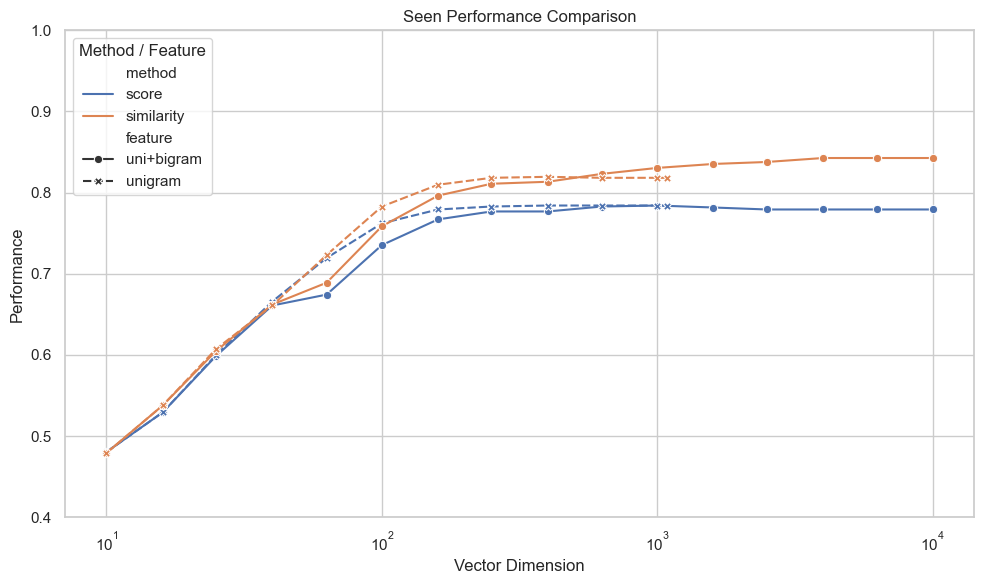

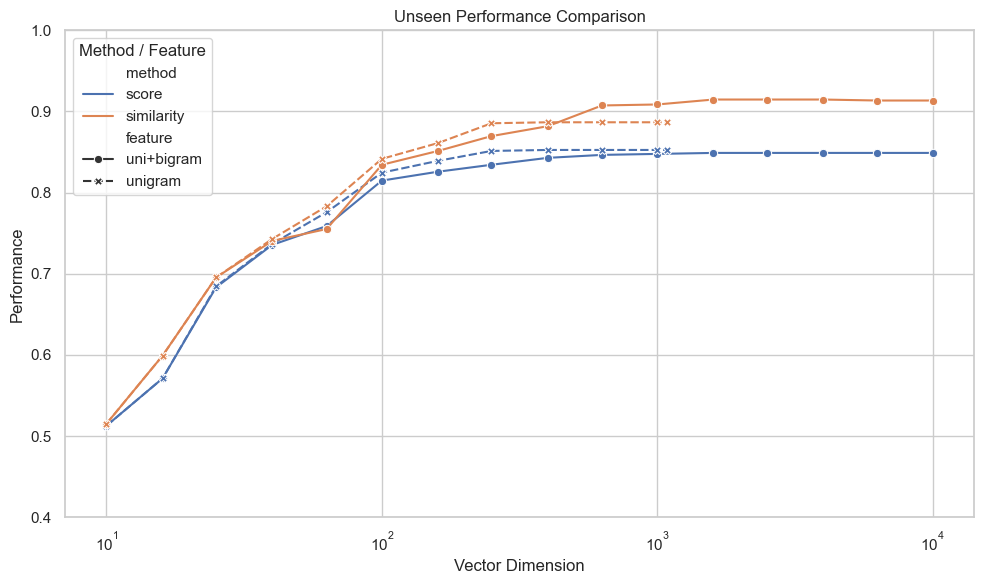

In [161]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.DataFrame(data_records)

# Optional: sort for cleaner plotting
df = df.sort_values(["dataset", "feature", "method", "dim"])

sns.set_theme(style="whitegrid")

for dataset_name in ["seen", "unseen"]:
    plt.figure(figsize=(10, 6))
    subset = df[df["dataset"] == dataset_name]

    sns.lineplot(
        data=subset,
        x="dim",
        y="value",
        hue="method",  # score vs similarity
        style="feature",  # unigram vs uni+bigram
        markers=True,
        dashes=True,
    )

    plt.title(f"{dataset_name.capitalize()} Performance Comparison")
    plt.xlabel("Vector Dimension")
    plt.ylabel("Performance")
    plt.ylim(0.4, 1)
    plt.xscale("log")
    plt.legend(title="Method / Feature")
    plt.tight_layout()
    plt.show()

In [159]:
for i in vector_dimensions:
    print(i, end=" ")

10 16 25 40 63 100 160 250 400 630 1000 1600 2500 4000 6300 10000 